In [1]:
import numpy as np
from qiskit import __version__
from qiskit.visualization import array_to_latex

## Vectors and matrices

In [9]:
ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

In [10]:
#operations represented as matrices
M1 = np.array([[1, 1], [0, 0]]) # f(a) = 0
M2 = np.array([[1, 0], [0, 1]]) # f(a) = a

In [11]:
display(array_to_latex(M1 @ ket1))

<IPython.core.display.Latex object>

In [12]:
display(array_to_latex(M1 @ M2))

<IPython.core.display.Latex object>

## State vectors

In [3]:
from qiskit.quantum_info import Statevector

In [14]:
u = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])
w = Statevector([1/3, 2/3])

In [15]:
display(u.draw("text"))

[0.70710678+0.j,0.70710678+0.j]

In [16]:
display(u.draw("latex"))

<IPython.core.display.Latex object>

In [17]:
display(u.draw("latex_source"))

'\\frac{\\sqrt{2}}{2} |0\\rangle+\\frac{\\sqrt{2}}{2} |1\\rangle'

In [18]:
display(u.is_valid())

True

In [19]:
display(w.is_valid())

False

In [20]:
qtrit = Statevector([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)])
display(qtrit.is_valid())

True

## Measurement

In [4]:
v = Statevector([(1 + 2.0j)/3, -2/3])
display(v.draw("latex"))

<IPython.core.display.Latex object>

In [5]:
outcome, post_measurement_state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(post_measurement_state.draw("latex"))

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

In [32]:
post_measurement_state.is_valid()

True

In [47]:
qtrit = Statevector([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)])

In [46]:
outcome, post_measurement_state = qtrit.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(post_measurement_state.draw("latex"))
display(post_measurement_state.is_valid())

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

True

💡 Statevector will throw an error if the measure method is applied to an invalid quantum state vector.  
```ValueError: Probabilities do not sum to 1. See Notes section of docstring for more information.```

In [49]:
w = Statevector([1/3, 2/3])
display(w.is_valid())

False

In [55]:
try: 
    outcome, post_measurement_state = w.measure()  #this line of code will throw an error
except Exception as e:
    print("An exception occured: ",e.__class__)

An exception occured:  <class 'ValueError'>


### Simulation of any number of measurements

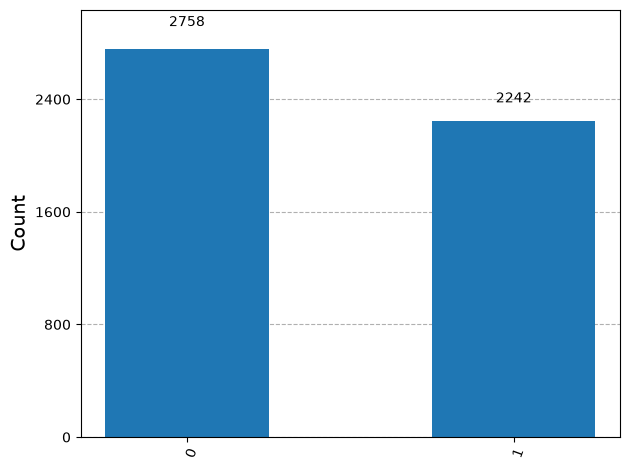

In [17]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(5000)
plot_histogram(statistics)

## Operations

In [18]:
from qiskit.quantum_info import Operator

In [20]:
Y = Operator([[0, -1j],[1j, 0]])
H = Operator([[1 / np.sqrt(2), 1 / np.sqrt(2)], [1 / np.sqrt(2), -1 / np.sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / np.sqrt(2)]])

In [23]:
display(H.is_unitary())

True

In [26]:
display(S.draw("latex"))
display(T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [28]:
v = Statevector([1, 0])
display(v.draw("latex"))

<IPython.core.display.Latex object>

In [31]:
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

## Quantum Circuits

In [7]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector

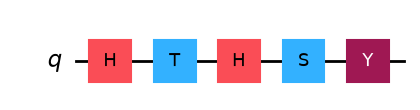

In [ ]:
circuit = QuantumCircuit(1) #quantum circuit with 1 qubit

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

In [8]:
operator_from_circuit = Operator.from_circuit(circuit)
display(operator_from_circuit.draw("latex"))

<IPython.core.display.Latex object>

In [9]:
ket0 = Statevector([1, 0])
v = ket0.evolve(operator_from_circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

In [12]:
v.probabilities()

array([0.14644661, 0.85355339])

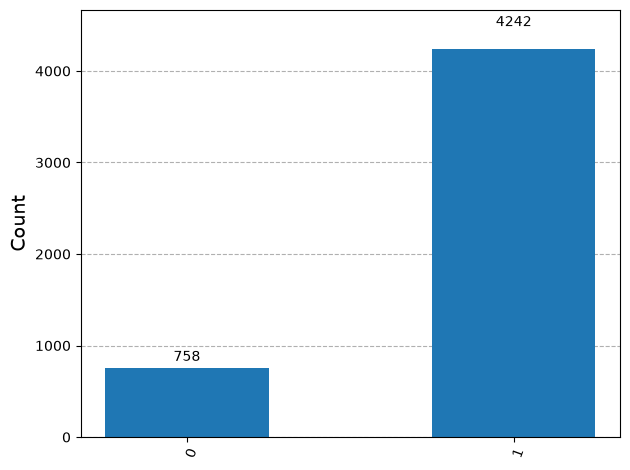

In [13]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(5000)
plot_histogram(statistics)